In [1]:
!pip install bertopic
!pip install nltk
# !pip install keybert
# !pip install keyphrase-vectorizers
# !pip install ctransformers[cuda]
# !pip install --upgrade git+https://github.com/huggingface/transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

In [2]:
import pandas as pd
import numpy as np
import torch
import transformers
from bertopic import BERTopic
import os
from sentence_transformers import SentenceTransformer
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN
from transformers import AutoTokenizer, pipeline
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import TextGeneration
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import openai
import lightgbm as lgb
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, OpenAI, PartOfSpeech
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.decomposition import PCA
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [5]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
df1 = pd.read_csv('../data/letters_2021_processed.csv')
df1 = df1[['s1_s2', 'full_text', 'LETTER_GENDER']]
df1 = df1.rename(columns={'LETTER_GENDER':'label'})

In [6]:
df2 = pd.read_csv('../data/sentence_sets_trimmed_processed.csv')
df2 = df2[['s1_s2', 'full_text', 'applicant_gender']]
df2 = df2.rename(columns={'applicant_gender':'label'})

In [7]:
df = pd.concat([df1, df2], ignore_index=True)

In [8]:
gender_label_mapping = {
    'F':0,
    'female':0,
    'M':1,
    'male':1
}

In [9]:
df['label'] = df['label'].replace(gender_label_mapping)

# Process Data

In [10]:
# df['s1_s2'] = df['s1_s2'].str.replace(r'identifier', '', case=False, regex=True).str.strip()
# df['s1_s2'] = df['s1_s2'].str.replace(r'mx', '', case=False, regex=True).str.strip()

In [11]:
letters = df['s1_s2']
sentences = [sent_tokenize(letter) for letter in letters]
sentences = pd.concat([df, pd.Series(sentences, name='sentences')], axis=1)
sentences = sentences[['sentences']].explode('sentences')
df_sentences = pd.merge(df, sentences, left_index=True, right_index=True)

In [13]:
# sentences = sentences['sentences'].tolist()

In [14]:
# with open("sentences.txt", "w") as f:
#     f.writelines(sentence + "\n" for sentence in sentences)

# Topic Modeling

In [ ]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
embeddings = embedding_model.encode(sentences['sentences'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/4850 [00:00<?, ?it/s]

In [ ]:
pca_model = PCA(n_components=5, random_state=42)

kmeans_model = KMeans(n_clusters=30, random_state=42, n_init="auto")

vectorizer_model = CountVectorizer(stop_words='english', min_df=2, ngram_range=(1, 2))

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

In [ ]:
# KeyBERT
keybert_model = KeyBERTInspired()

# Part-of-Speech
pos_model = PartOfSpeech("en_core_web_sm", top_n_words=10)

# MMR
mmr_model = MaximalMarginalRelevance(diversity=0.3)

# GPT-3.5
client = openai.OpenAI(api_key="sk-...")
prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]
The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short but highly descriptive topic label of at most 5 words. Make sure it is in the following format:
topic: <topic label>
"""
openai_model = OpenAI(client, model="gpt-3.5-turbo", exponential_backoff=True, chat=True, prompt=prompt)

# All representation models
representation_model = {
    "KeyBERT": keybert_model,
    # "OpenAI": openai_model,  # Uncomment if you will use OpenAI
    "MMR": mmr_model,
    "POS": pos_model,
    # "zephyr": zephyr

}

In [ ]:
topic_model = BERTopic(

  # Pipeline models
  embedding_model=embedding_model,
  umap_model=pca_model,
  hdbscan_model=kmeans_model,
  vectorizer_model=vectorizer_model,
  ctfidf_model=ctfidf_model,
  representation_model=representation_model,

  # Hyperparameters
  top_n_words=10,
  verbose=True
)

# Train model
topics, probs = topic_model.fit_transform(df_sentences['sentences'].tolist(), embeddings)



2025-02-13 22:19:45,160 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-02-13 22:19:45,439 - BERTopic - Dimensionality - Completed ✓
2025-02-13 22:19:45,455 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-02-13 22:19:46,862 - BERTopic - Cluster - Completed ✓
2025-02-13 22:19:46,888 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-02-13 22:19:59,528 - BERTopic - Representation - Completed ✓


# Save Model

In [ ]:
# embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
# topic_model.save("../saved_models/topic_model_pca_kmeans/", serialization="safetensors", save_ctfidf=True, save_embedding_model=embedding_model)

# Analyze Topics

In [ ]:
topic_info = topic_model.get_topic_info()

In [ ]:
topic_info

,Topic,Count,Name,Representation,KeyBERT,MMR,POS,Representative_Docs
0,0,9601,0_patients_staff_families_patients families,"[patients, staff, families, patients families,...","[patients colleagues, patients ease, caring pa...","[patients families, bedside manner, rapport pa...","[patients, staff, families, bedside, rapport, ...",[[ spent one month with where they gained...
1,1,7081,1_hard_personality_hard working_ethic,"[hard, personality, hard working, ethic, demea...","[qualities, positive attitude, demeanor, perso...","[personality, hard working, demeanor, work eth...","[hard, personality, ethic, demeanor, humble, i...","[they is a collaborative team member , with a..."
2,2,6943,2_room_operating_operating room_patient,"[room, operating, operating room, patient, icu...","[preoperative, patients, inpatient, operating ...","[operating room, icu, patients, procedures, ai...","[room, operating, patient, icu, care, patients...",[had multiple opportunities to observe and ult...
3,3,6725,3_residency program_residency_program_resident,"[residency program, residency, program, reside...","[recommend residency, residency program, progr...","[residency program, addition residency, recomm...","[residency, program, resident, asset, excellen...",[| believe they would be an excellent reside...
4,4,6717,4_anesthesiologist_anesthesiology_career_caree...,"[anesthesiologist, anesthesiology, career, car...","[excellent anesthesiologist, future anesthesio...","[anesthesiologist, career anesthesiology, fiel...","[anesthesiologist, anesthesiology, career, fie...",[they will make an excellent anesthesiologist...
5,5,6634,5_medical students_students_medical student_st...,"[medical students, students, medical student, ...","[medical students, medical student, student me...","[medical students, students, medical student, ...","[medical students, students, medical student, ...",[they is in the top 5 % of medical students t...
6,6,6512,6_patient_patients_questions_treatment,"[patient, patients, questions, treatment, plan...","[patient presentations, clinical, patients, pl...","[patients, questions, rounds, plans, diagnoses...","[patient, patients, questions, treatment, roun...",[every suggestion i gave them was taken to h...
7,7,6324,7_physician_medical knowledge_clinical_excelle...,"[physician, medical knowledge, clinical, excel...","[excellent physician, great physician, physici...","[physician, medical knowledge, excellent physi...","[physician, medical knowledge, clinical, excel...",[that - will make them .an.excellent physician...
8,8,6309,8_clerkship_internal medicine_hospital_internal,"[clerkship, internal medicine, hospital, inter...","[medicine clerkship, medical center, attending...","[clerkship, internal medicine, hospital, clini...","[clerkship, internal medicine, hospital, inter...",[i had the opportunity to work with as an e...
9,9,6294,9_university_school_medical school_college,"[university, school, medical school, college, ...","[medical college, medical school, college medi...","[university, medical school, graduated, underg...","[school, medical school, degree, undergraduate...",[’s leadership experience includes serving as ...


In [ ]:
topic_labels = topic_model.generate_topic_labels(nr_words=5,
                                                 topic_prefix=True,
                                                 word_length=100,
                                                 separator="||",
                                                 aspect=None)

In [ ]:
topic_model.set_topic_labels(topic_labels)

In [ ]:
topic_mapping = dict(zip(topic_model.get_topic_info()['Topic'], topic_model.get_topic_info()['CustomName']))
topic_mapping = {f'topic_{key}': value for key, value in topic_mapping.items()}

In [ ]:
df_sentences['topic'] = topics

# Create Topics Dataframe

In [ ]:
topics_df = df_sentences.copy()
topics_df['topic'] = topics_df['topic'].astype(str)
topics_df = topics_df.groupby(topics_df.index).agg({'topic':' '.join})
topics_df = pd.DataFrame(topics_df)
topics_df = topics_df['topic'].apply(lambda x:x.split(' '))
topics_df = topics_df.reset_index()
all_topics = set(cat for sublist in topics_df['topic'] for cat in sublist)
for topic in all_topics:
    topics_df[topic] = topics_df['topic'].apply(lambda x: 1 if topic in x else 0)
topics_df = topics_df.drop(columns=['index', 'topic'])
topics_df.columns = 'topic_' + topics_df.columns
df_sentences_collapsed = df_sentences[['s1_s2', 'full_text', 'label']].drop_duplicates()
topics_df = pd.merge(df_sentences_collapsed, topics_df, left_index=True, right_index=True)

# Build ML Model

In [ ]:
X = topics_df.drop(columns=['s1_s2', 'full_text', 'label'])
y = topics_df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [ ]:
clf = lgb.LGBMClassifier(is_unbalance=True, n_estimators = 2000, random_state=0, verbose=-1)

In [ ]:
best_classifier = None
best_f1_score = float('-inf')
for i, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
    print(f"Fold {i}:")
    # print(f"  Train: index={train_index}")
    # print(f"  Test:  index={val_index}")

    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    clf.fit(X_train_fold, y_train_fold)

    y_pred = clf.predict(X_val_fold)

    print(classification_report(y_val_fold, y_pred))

    print(confusion_matrix(y_val_fold, y_pred))

    f1 = f1_score(y_val_fold, y_pred, average='weighted')

    if f1 > best_f1_score:
      print('BEST F1 SCORE: ', f1)
      best_f1_score = f1
      best_classifier = clf






Fold 0:
              precision    recall  f1-score   support

           0       0.32      0.27      0.29       446
           1       0.69      0.73      0.71       991

    accuracy                           0.59      1437
   macro avg       0.50      0.50      0.50      1437
weighted avg       0.58      0.59      0.58      1437

[[122 324]
 [263 728]]
BEST F1 SCORE:  0.5826157366451097
Fold 1:
              precision    recall  f1-score   support

           0       0.32      0.24      0.28       446
           1       0.69      0.77      0.73       991

    accuracy                           0.61      1437
   macro avg       0.51      0.51      0.50      1437
weighted avg       0.58      0.61      0.59      1437

[[108 338]
 [225 766]]
BEST F1 SCORE:  0.5903617056278506
Fold 2:
              precision    recall  f1-score   support

           0       0.34      0.27      0.30       446
           1       0.70      0.77      0.73       991

    accuracy                           0.6

Most Important Features:
                                              Feature  Importance
11  5||medical students||students||medical student...        2633
26  4||anesthesiologist||anesthesiology||career||c...        2486
0   1||hard||personality||hard working||ethic||dem...        2465
6   3||residency program||residency||program||resi...        2451
27  8||clerkship||internal medicine||hospital||int...        2322
5   7||physician||medical knowledge||clinical||exc...        2290
17     12||academic||students||student||honors||usmle        2262
7    2||room||operating||operating room||patient||icu        2219
23  0||patients||staff||families||patients familie...        2211
12  11||skills||knowledge||medical knowledge||clin...        2197
21  20||team||player||team player||rotation||membe...        2186
18     15||impressed||ethic||work ethic||work||showed        2159
15  16||anesthesiology residency||anesthesia resid...        2103
29  19||questions||presentations||asked||feedback|.

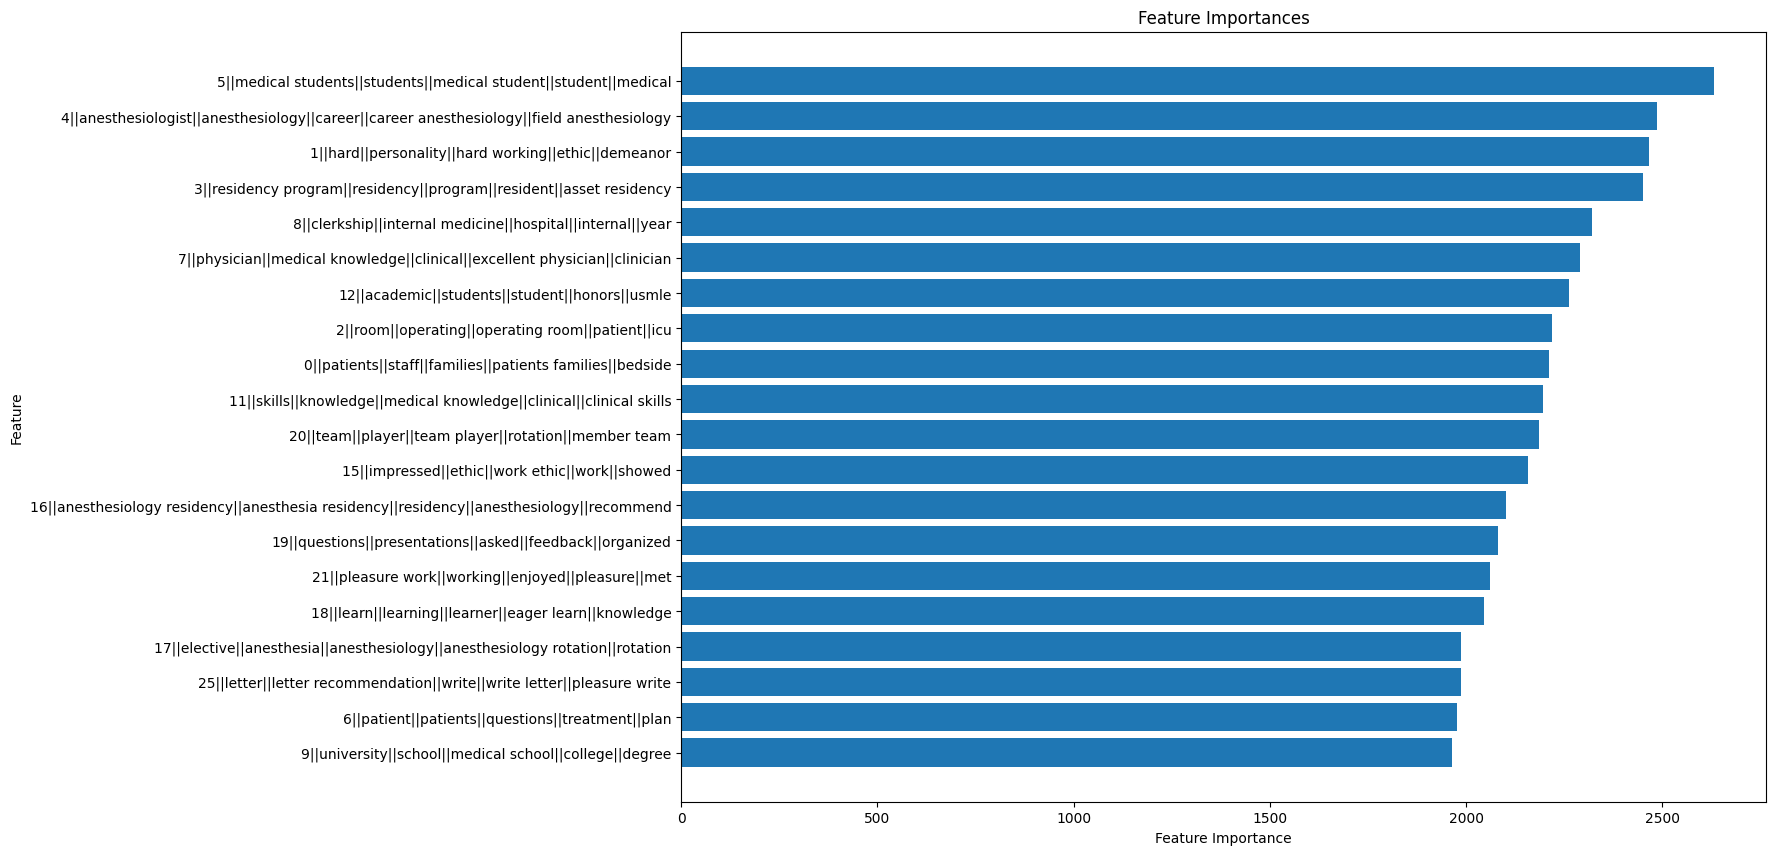

In [ ]:
importances = best_classifier.feature_importances_

feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)[:20]
feature_importance_df['Feature'] = feature_importance_df['Feature'].map(topic_mapping)

print("Most Important Features:")
print(feature_importance_df)

plt.figure(figsize=(14, 10))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')

plt.gca().invert_yaxis()

plt.show()

# Apply on Test Set

In [ ]:
y_test_preds = best_classifier.predict(X_test)

In [ ]:
print(classification_report(y_test, y_test_preds))

              precision    recall  f1-score   support

           0       0.32      0.23      0.27       557
           1       0.69      0.77      0.73      1239

    accuracy                           0.61      1796
   macro avg       0.50      0.50      0.50      1796
weighted avg       0.58      0.61      0.59      1796



# Analyze Important Topics

In [ ]:
reduced_embeddings = PCA(n_components=2).fit_transform(embeddings)
topic_model.visualize_documents(sentences['sentences'].tolist(), hide_annotations=True, reduced_embeddings=reduced_embeddings)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,CustomName,Representation,KeyBERT,MMR,POS,Representative_Docs
0,0,9601,0_patients_staff_families_patients families,0||patients||staff||families||patients familie...,"[patients, staff, families, patients families,...","[patients colleagues, liked patients, patients...","[patients families, bedside manner, rapport pa...","[patients, staff, families, bedside, rapport, ...","[best of all, is a kind, gentle, and friend..."
1,1,7080,1_hard_personality_hard working_ethic,1||hard||personality||hard working||ethic||dem...,"[hard, personality, hard working, ethic, demea...","[qualities, positive attitude, demeanor, commu...","[personality, hard working, demeanor, work eth...","[hard, personality, ethic, demeanor, humble, i...","[secondly , they is extremely hard working a..."
2,2,6944,2_room_operating_operating room_patient,2||room||operating||operating room||patient||icu,"[room, operating, operating room, patient, icu...","[preoperative, intubations, intubation, airway...","[operating room, icu, patients, procedures, ai...","[room, operating, patient, icu, care, patients...",[had multiple opportunities to observe and ult...
3,3,6725,3_residency program_residency_program_resident,3||residency program||residency||program||resi...,"[residency program, residency, program, reside...","[recommend residency, residency program, progr...","[residency program, addition residency, recomm...","[residency, program, resident, asset, excellen...",[| believe they would be an excellent reside...
4,4,6717,4_anesthesiologist_anesthesiology_career_caree...,4||anesthesiologist||anesthesiology||career||c...,"[anesthesiologist, anesthesiology, career, car...","[excellent anesthesiologist, future anesthesio...","[anesthesiologist, career anesthesiology, fiel...","[anesthesiologist, anesthesiology, career, fie...","[will make an excellent anesthesiologist!, the..."
5,5,6635,5_medical students_students_medical student_st...,5||medical students||students||medical student...,"[medical students, students, medical student, ...","[medical students, medical student, student me...","[medical students, students, medical student, ...","[medical students, students, medical student, ...","[in my experience, they is in the top 10% of..."
6,6,6513,6_patient_patients_questions_treatment,6||patient||patients||questions||treatment||plan,"[patient, patients, questions, treatment, plan...","[patients, read patients, plans patients, pati...","[patients, questions, rounds, plans, diagnoses...","[patient, patients, questions, treatment, roun...",[their enthusiasm was particularly evident fr...
7,7,6321,7_physician_medical knowledge_clinical_excelle...,7||physician||medical knowledge||clinical||exc...,"[physician, medical knowledge, clinical, excel...","[clinical skills, clinical knowledge, knowledg...","[physician, medical knowledge, excellent physi...","[physician, medical knowledge, clinical, excel...","[is articulate , well - read , and able to uti..."
8,8,6313,8_clerkship_internal medicine_hospital_internal,8||clerkship||internal medicine||hospital||int...,"[clerkship, internal medicine, hospital, inter...","[medicine clerkship, inpatient, medical center...","[clerkship, internal medicine, hospital, clini...","[clerkship, internal medicine, hospital, inter...",[as associate program director and academic ho...
9,9,6296,9_university_school_medical school_college,9||university||school||medical school||college...,"[university, school, medical school, college, ...","[medical college, medical school, medical stud...","[university, medical school, graduated, underg...","[school, medical school, degree, undergraduate...",[completed their bachelor of science degree ...
